Step 1: Setup and load Data

In [32]:
import kagglehub
import shutil
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import seaborn as sns
from sklearn.metrics import mean_absolute_error
# 1. Download the dataset (this goes to the default cache folder first)
print("Downloading dataset...")
cache_path = kagglehub.dataset_download("lainguyn123/student-performance-factors")

# 2. Define your 'Special Path' where you want the data to live
# (Change this to your actual folder path)
target_path = "D:/Work/HandsOnExperienceML/machineLearningTasks01/DataSets/"
# 3. Move the files from cache to your special path
print(f"Moving files from {cache_path} to {target_path}...")
# Check if target already exists to avoid errors, then move
if os.path.exists(target_path):
    print("Target folder already exists. Deleting it to replace with new download...")
    shutil.rmtree(target_path) # clear old version if it exists
shutil.move(cache_path, target_path)

print("Success! Dataset is now ready at:", target_path)

100%|██████████| 93.9k/93.9k [00:00<00:00, 242kB/s]

Extracting files...
Moving files from C:\Users\Lenovo\.cache\kagglehub\datasets\lainguyn123\student-performance-factors\versions\9 to D:/Work/HandsOnExperienceML/machineLearningTasks01/DataSets/...
Target folder already exists. Deleting it to replace with new download...
Success! Dataset is now ready at: D:/Work/HandsOnExperienceML/machineLearningTasks01/DataSets/


In [33]:
#Load the dataset
df = pd.read_csv('DataSets/StudentPerformanceFactors.csv')
#Inspect the dataset
print("Dataset loaded successfully. Here are the first few rows:")
print(df.head().T)

Dataset loaded successfully. Here are the first few rows:
                                      0         1             2            3  \
Hours_Studied                        23        19            24           29   
Attendance                           84        64            98           89   
Parental_Involvement                Low       Low        Medium          Low   
Access_to_Resources                High    Medium        Medium       Medium   
Extracurricular_Activities           No        No           Yes          Yes   
Sleep_Hours                           7         8             7            8   
Previous_Scores                      73        59            91           98   
Motivation_Level                    Low       Low        Medium       Medium   
Internet_Access                     Yes       Yes           Yes          Yes   
Tutoring_Sessions                     0         2             2            1   
Family_Income                       Low    Medium        Mediu

Step 2: Exploratory Data Analysis (EDA)

In [35]:
#Check for missing values
print("\nChecking for missing values:")
print(df.isnull().sum())


Checking for missing values:
Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64


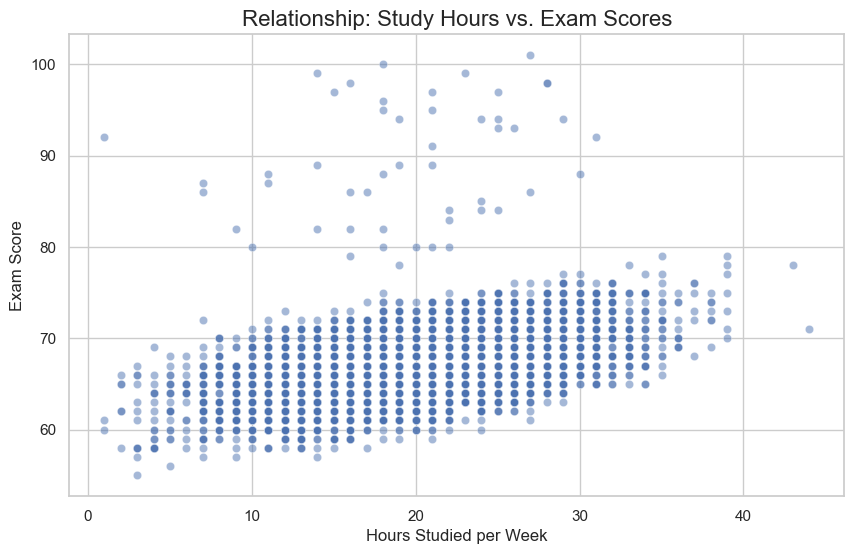

In [36]:
#Visualization: Study Hours vs. Exam Scores
# Set the visual style
sns.set(style="whitegrid")

# Create a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Hours_Studied', y='Exam_Score', data=df, alpha=0.5)

plt.title('Relationship: Study Hours vs. Exam Scores', fontsize=16)
plt.xlabel('Hours Studied per Week', fontsize=12)
plt.ylabel('Exam Score', fontsize=12)
plt.show()

Step 3: Prepare the Data (Preprocessing)

In [37]:
# Define features X and target variable y
X = df[['Hours_Studied']]
y = df['Exam_Score']
# Split the data into training 80% and testing sets 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")


Training set size: 5285 samples
Testing set size: 1322 samples


Step 4: Train the Model (Best Fit Line)

In [39]:
# Initializing model
model = LinearRegression()
#Training model
model.fit(X_train, y_train)
#Output model coefficients (equation parameters)
print("\nModel Trained Successfully.")
print(f"Intercept: {model.intercept_}")
print(f"Coefficient for Hours_Studied: {model.coef_[0]}")
print(f"Equation: Score = {model.coef_[0]:.2f} * (Hours) + {model.intercept_:.2f}")


Model Trained Successfully.
Intercept: 61.511167469044246
Coefficient for Hours_Studied: 0.2856687444430867
Equation: Score = 0.29 * (Hours) + 61.51


The Equation: Score = 0.29 * (Hours) + 61.51
; For very hour you study your score goes up approx by 0.3 points!

Step 5: Evaluation & Visalisation


Model R²-Score: 0.23
Mean Absolute Error: 2.45


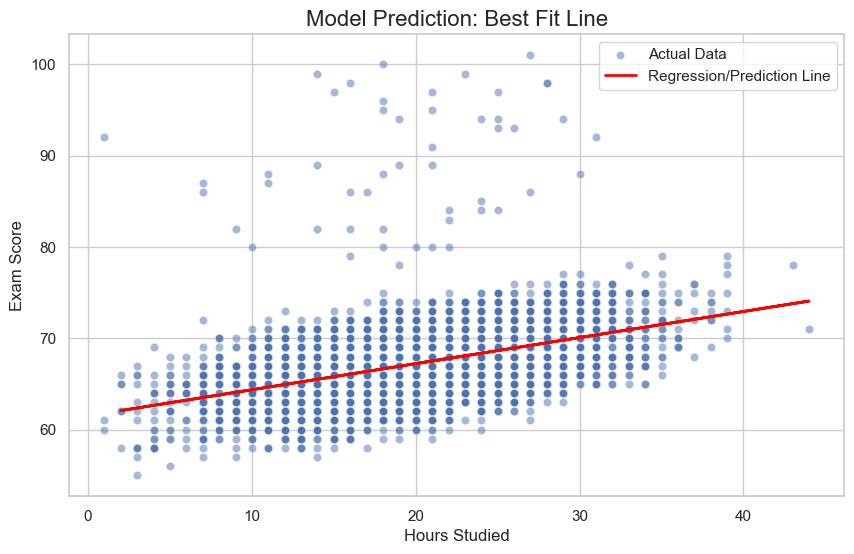

In [40]:

# Make predictions on text set 20%
y_pred = model.predict(X_test)
# Evaluate the model(Calc accuracy using R² score metric)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f"\nModel R²-Score: {r2:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")
# Visualize the regression line
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Hours_Studied', y='Exam_Score', data=df, alpha=0.5, label='Actual Data')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression/Prediction Line')
plt.title('Model Prediction: Best Fit Line', fontsize=16)
plt.xlabel('Hours Studied', fontsize=12)
plt.ylabel('Exam Score', fontsize=12)
plt.legend()
plt.show()


Step 6: Save Model

In [42]:
import joblib
#Save model  to a file
joblib.dump(model, 'SavedModel/student_performance_model.pkl')
print("\nModel saved as 'student_performance_model.pkl'")



Model saved as 'student_performance_model.pkl'


Summary: Analyzed dataset of 6k+ students to identify the corr between study habits and performance. Using Python and Scikit-learn, built a linear regression model that predicts exam scores with a Mean Absolute Error of approx 2.4 points, providing insights for educational forecasting!